# EMPIAR-10045: high-order KLT spectrum and max_order selection

This notebook determines how large the spherical-harmonic ceiling must be for **EMPIAR-10045, tomogram 08**. It starts from the checkpointed, whitened particle radial power spectral density (RPSD), solves the radial Fredholm eigenproblem for a deliberately large range of angular orders, and measures the covariance energy discarded by angular and template-count truncation.

The raw approximately 30 GiB tomogram is **not streamed again**. Stages 1–5 already produced everything required:

- **04_whitened_patch_rpsds.pkl** contains the radial grid and whitened patch RPSDs.
- **05_whitened_als.pkl** contains the ALS estimates of the whitened particle and noise RPSDs.
- **00_manifest.json** contains the EMPIAR geometry and Fredholm support radius.

> **Important index distinction:** \(K=150\) is the radial quadrature/eigenproblem dimension. The experiment's large max_order is an exclusive angular ceiling: max_order \(=180\) solves \(\ell=0,\ldots,179\). Within each angular block, \(n\) indexes radial eigenfunctions and \(m=-\ell,\ldots,\ell\) gives the \(2\ell+1\) spherical-harmonic degeneracy.


## 1. Configuration and checkpoint loading

Run the notebook with the same environment as the detector experiments (currently the **moshiko** environment). With RECOMPUTE set to False, a compatible saved 180-order spectrum is loaded immediately. Set it to True only if the particle PSD or solver geometry changes.


In [11]:
from __future__ import annotations

import hashlib
import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy.special import roots_legendre
from tqdm.auto import tqdm

def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "kltpicker_3d").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")

REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

from kltpicker_3d.fredholm_solver import (
    INVERSE_FOURIER_NORMALIZATION_3D,
    solve_radial_fredholm_equation,
)
from kltpicker_3d.utils import trigonometric_interpolation

RESULTS_DIR = REPOSITORY_ROOT / "results/empiar-10045-bandpass-block-qr"
OUTPUT_DIR = REPOSITORY_ROOT / "results/empiar-10045-max-order-analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LEGENDRE_ORDER = 150       # radial quadrature dimension K
MAX_ORDER = 180           # exclusive: ell = 0, ..., 179
ENERGY_FRACTION = 0.99
TEMPLATE_CAP = 1000
RECOMPUTE = False
TRACE_TARGETS = (0.80, 0.90, 0.95, 0.99)

def load_pickle(path: Path):
    with path.open("rb") as stream:
        return pickle.load(stream)

required = [
    RESULTS_DIR / "00_manifest.json",
    RESULTS_DIR / "04_whitened_patch_rpsds.pkl",
    RESULTS_DIR / "05_whitened_als.pkl",
]
missing = [path for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Missing stage checkpoint(s): {missing}")

manifest = json.loads(required[0].read_text())
extraction = load_pickle(required[1])
whitened_model = load_pickle(required[2])

radial_points = np.asarray(extraction.radial_points, dtype=np.float64)
particle_psd = np.asarray(whitened_model.particle_psd, dtype=np.float64)
noise_psd = np.asarray(whitened_model.noise_psd, dtype=np.float64)
support_radius = float(manifest["fredholm_radius_voxels"])
bandlimit = float(radial_points[-1])

display(Markdown(
    f"**Tomogram:** {Path(manifest['input']).name}  \n"
    f"**Patch grid:** {tuple(extraction.patch_grid_shape)} "
    f"({len(extraction.rpsds):,} patches of side {extraction.patch_size})  \n"
    f"**Fredholm support:** \(a={support_radius:.3f}\) voxels  \n"
    f"**Bandlimit:** \(c={bandlimit:.6f}\) rad/voxel  \n"
    f"**Space-bandwidth product:** \(ac={support_radius * bandlimit:.3f}\)"
))


**Tomogram:** IS002_291013_008.mrc  
**Patch grid:** (5, 39, 41) (7,995 patches of side 93)  
**Fredholm support:** \(a=47.443\) voxels  
**Bandlimit:** \(c=3.141593\) rad/voxel  
**Space-bandwidth product:** \(ac=149.048\)

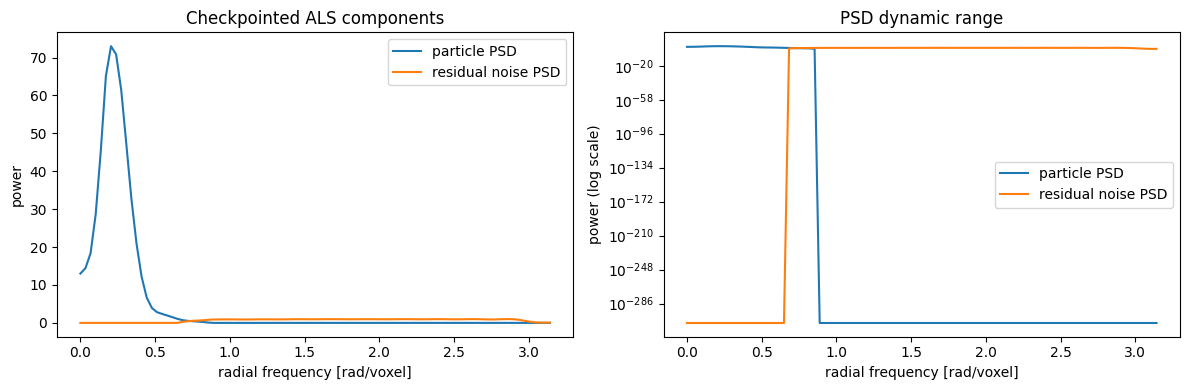

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(radial_points, particle_psd, label="particle PSD")
axes[0].plot(radial_points, noise_psd, label="residual noise PSD")
axes[0].set(
    xlabel="radial frequency [rad/voxel]",
    ylabel="power",
    title="Checkpointed ALS components",
)
axes[0].legend()

tiny = np.finfo(float).tiny
axes[1].semilogy(radial_points, np.maximum(particle_psd, tiny), label="particle PSD")
axes[1].semilogy(radial_points, np.maximum(noise_psd, tiny), label="residual noise PSD")
axes[1].set(
    xlabel="radial frequency [rad/voxel]",
    ylabel="power (log scale)",
    title="PSD dynamic range",
)
axes[1].legend()
fig.tight_layout()
plt.show()


## 2. Fredholm quadrature and the independent trace reference

For this repository's Fourier convention,

\[
C(h)=\frac{1}{(2\pi)^3}\int_{\mathbb{R}^3}G(\omega)e^{i\omega\cdot h}\,d\omega.
\]

For an isotropic spectrum,

\[
C(0)=\frac{4\pi}{(2\pi)^3}\int_0^c G(r)r^2\,dr.
\]

The covariance operator is restricted to the spatial ball \(B_a\), so its expected trace is \(\lvert B_a\rvert C(0)\). This gives an independent normalization target: as the angular ceiling grows, the degeneracy-weighted Fredholm eigenvalues must converge to this trace. The checkpointed RPSD is first interpolated onto the \(K=150\) Gauss-Legendre frequency nodes used by the solver.


In [13]:
legendre_nodes, legendre_weights = roots_legendre(LEGENDRE_ORDER)
frequency_nodes = (bandlimit / 2) * (legendre_nodes + 1)
particle_psd_nodes = np.maximum(
    np.asarray(
        trigonometric_interpolation(radial_points, particle_psd, frequency_nodes),
        dtype=np.float64,
    ),
    0.0,
)

covariance_at_zero = (
    4
    * np.pi
    * INVERSE_FOURIER_NORMALIZATION_3D
    * (bandlimit / 2)
    * np.sum(legendre_weights * particle_psd_nodes * frequency_nodes**2)
)
ball_volume = 4 * np.pi * support_radius**3 / 3
expected_trace = ball_volume * covariance_at_zero

print(f"(2pi)^-3 normalization       = {INVERSE_FOURIER_NORMALIZATION_3D:.12g}")
print(f"Particle covariance C(0)     = {covariance_at_zero:.9g}")
print(f"Expected covariance trace    = {expected_trace:.9g}")


(2pi)^-3 normalization       = 0.00403144180415
Particle covariance C(0)     = 0.0883101515
Expected covariance trace    = 39502.6867


## 3. High-order angular sweep

For each \(\ell\), the solver diagonalizes a \(K\times K\) radial Nyström matrix and returns \(\lambda_{\ell n}\). One radial mode represents the complete \(m\) multiplet, so its covariance-energy contribution is

\[
E_{\ell n}=(2\ell+1)\lambda_{\ell n}.
\]

A full 180-block recomputation is CPU work and may take several minutes. The cache is accepted only when the PSD digest, \(K\), max_order, support radius, and bandlimit all match.


In [14]:
def array_digest(values: np.ndarray) -> str:
    contiguous = np.ascontiguousarray(values)
    return hashlib.sha256(contiguous.view(np.uint8)).hexdigest()

def solve_angular_spectrum() -> np.ndarray:
    spectrum = np.zeros((MAX_ORDER, LEGENDRE_ORDER), dtype=np.float64)
    for ell in tqdm(range(MAX_ORDER), desc="Fredholm angular sweep", unit="ell"):
        values, _, _ = solve_radial_fredholm_equation(
            particle_psd_nodes,
            N=ell,
            a=support_radius,
            c=bandlimit,
            K=LEGENDRE_ORDER,
        )
        spectrum[ell] = np.maximum(np.real(values), 0.0)
    return spectrum

cache_path = OUTPUT_DIR / "angular_eigenvalues.npz"
digest = array_digest(particle_psd_nodes)
eigenvalues = None

if cache_path.is_file() and not RECOMPUTE:
    with np.load(cache_path, allow_pickle=False) as cache:
        compatible = (
            int(cache["max_order"]) == MAX_ORDER
            and int(cache["legendre_order"]) == LEGENDRE_ORDER
            and float(cache["support_radius"]) == support_radius
            and float(cache["bandlimit"]) == bandlimit
            and str(cache["particle_psd_digest"]) == digest
        )
        if compatible:
            eigenvalues = np.asarray(cache["eigenvalues"], dtype=np.float64)
            print(f"Loaded compatible cache: {cache_path}")
        else:
            print("The existing cache is incompatible; recomputing.")

if eigenvalues is None:
    eigenvalues = solve_angular_spectrum()
    np.savez(
        cache_path,
        eigenvalues=eigenvalues,
        max_order=MAX_ORDER,
        legendre_order=LEGENDRE_ORDER,
        support_radius=support_radius,
        bandlimit=bandlimit,
        particle_psd_digest=digest,
    )
    print(f"Saved cache: {cache_path}")

print(f"Spectrum shape = {eigenvalues.shape}")


The existing cache is incompatible; recomputing.


Fredholm angular sweep:   0%|          | 0/180 [00:00<?, ?ell/s]

Saved cache: /scratch/home/moshemaymon/3D_KLT/results/empiar-10045-max-order-analysis/angular_eigenvalues.npz
Spectrum shape = (180, 150)


## 4. Angular energy decay and max_order truncation

The total energy in angular block \(\ell\) is

\[
E_\ell=(2\ell+1)\sum_n\lambda_{\ell n}.
\]

The cumulative curve directly answers the max_order question: if the detector keeps \(\ell<L\), what fraction of the full covariance trace is even available to the model?


target   max_order   largest ell   achieved fraction
   80%          67            66          80.304286%
   90%          98            97          90.088656%
   95%         116           115          95.253558%
   99%         135           134          99.098115%

Trace closure through ell=179: 100.000000000000%


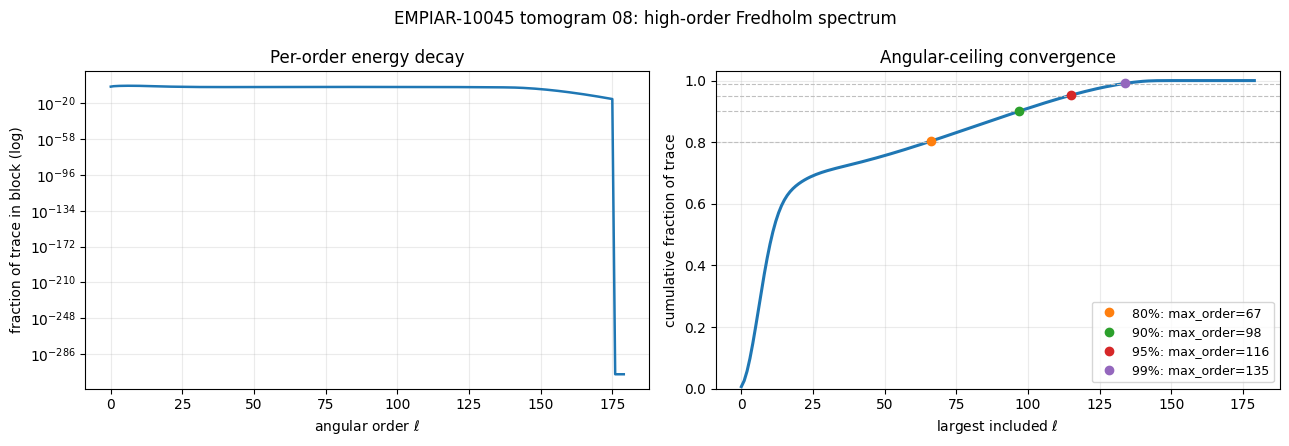

In [15]:
ells = np.arange(MAX_ORDER)
multiplicities_by_ell = 2 * ells + 1
block_energy = multiplicities_by_ell * eigenvalues.sum(axis=1)
block_trace_fraction = block_energy / expected_trace
cumulative_trace_fraction = np.cumsum(block_energy) / expected_trace

crossings = []
for target in TRACE_TARGETS:
    candidates = np.flatnonzero(cumulative_trace_fraction >= target)
    crossings.append((
        target,
        None if not candidates.size else int(candidates[0] + 1),
        None if not candidates.size else int(candidates[0]),
        np.nan if not candidates.size else float(cumulative_trace_fraction[candidates[0]]),
    ))

print("target   max_order   largest ell   achieved fraction")
for target, order_count, largest_ell, achieved in crossings:
    print(f"{target:6.0%}   {str(order_count):>9}   {str(largest_ell):>11}   {achieved:17.6%}")
print(f"\nTrace closure through ell={MAX_ORDER - 1}: {cumulative_trace_fraction[-1]:.12%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].semilogy(ells, np.maximum(block_trace_fraction, tiny), lw=1.8)
axes[0].set(
    xlabel=r"angular order $\ell$",
    ylabel="fraction of trace in block (log)",
    title="Per-order energy decay",
)
axes[0].grid(alpha=0.25)

axes[1].plot(ells, cumulative_trace_fraction, lw=2.2)
for target, order_count, largest_ell, achieved in crossings:
    axes[1].axhline(target, color="0.75", ls="--", lw=0.8)
    if largest_ell is not None:
        axes[1].plot(
            largest_ell, achieved, "o",
            label=f"{target:.0%}: max_order={order_count}",
        )
axes[1].set(
    xlabel=r"largest included $\ell$",
    ylabel="cumulative fraction of trace",
    title="Angular-ceiling convergence",
    ylim=(0, 1.03),
)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)
fig.suptitle("EMPIAR-10045 tomogram 08: high-order Fredholm spectrum")
fig.tight_layout()
plt.show()


## 5. Numerical rank: which radial solutions actually survive?

Each angular block is represented by a 150 by 150 numerical eigenproblem, but that does not imply 150 physically meaningful radial modes. High-n eigenvalues eventually fall to floating-point scale. We define the standard symmetric-eigenproblem tolerance

\[
\tau = K\,\epsilon_{\mathrm{float64}}\,\max_{\ell,n}\lambda_{\ell n},
\]

and treat a mode as numerically resolved only when \(\lambda_{\ell n}>\tau\). The tolerance table also verifies that removing these numerical crumbs has negligible effect on the covariance trace.


In [16]:
EIGENVALUE_RELATIVE_TOLERANCE = np.finfo(np.float64).eps * LEGENDRE_ORDER
eigenvalue_tolerance = EIGENVALUE_RELATIVE_TOLERANCE * float(eigenvalues.max())
numerically_significant = eigenvalues > eigenvalue_tolerance
positive_count = int(np.count_nonzero(eigenvalues > 0))
significant_count = int(np.count_nonzero(numerically_significant))
surviving_per_ell = numerically_significant.sum(axis=1)
surviving_indices = np.argwhere(numerically_significant)
largest_surviving_n = int(surviving_indices[:, 1].max())

weighted_eigenvalues = eigenvalues * multiplicities_by_ell[:, None]
resolved_trace = float(weighted_eigenvalues[numerically_significant].sum())
discarded_trace_fraction = 1.0 - resolved_trace / float(weighted_eigenvalues.sum())

print(f"Nominal radial solutions:          {eigenvalues.size:,}")
print(f"Strictly positive solutions:       {positive_count:,}")
print(f"Numerically resolved solutions:    {significant_count:,}")
print(f"Relative tolerance:                {EIGENVALUE_RELATIVE_TOLERANCE:.6g}")
print(f"Absolute eigenvalue tolerance:     {eigenvalue_tolerance:.6g}")
print(f"Largest surviving radial index n:  {largest_surviving_n}")
print(
    "Surviving modes per ell:         "
    f"min={surviving_per_ell.min()}, median={np.median(surviving_per_ell):.0f}, "
    f"max={surviving_per_ell.max()}"
)
print(f"Trace fraction discarded:          {discarded_trace_fraction:.3e}")


Nominal radial solutions:          27,000
Strictly positive solutions:       3,839
Numerically resolved solutions:    3,705
Relative tolerance:                3.33067e-14
Absolute eigenvalue tolerance:     2.33544e-12
Largest surviving radial index n:  53
Surviving modes per ell:         min=0, median=18, max=54
Trace fraction discarded:          3.331e-13


relative tolerance   surviving modes   retained trace   largest n
        lambda > 0             3,839   100.000000000%          53
          3.33e-14             3,705   100.000000000%          53
             1e-12             3,585   99.999999999%          52
             1e-10             3,413   99.999999911%          51
             1e-08             3,233   99.999990480%          49
             1e-06             3,054   99.999013106%          48


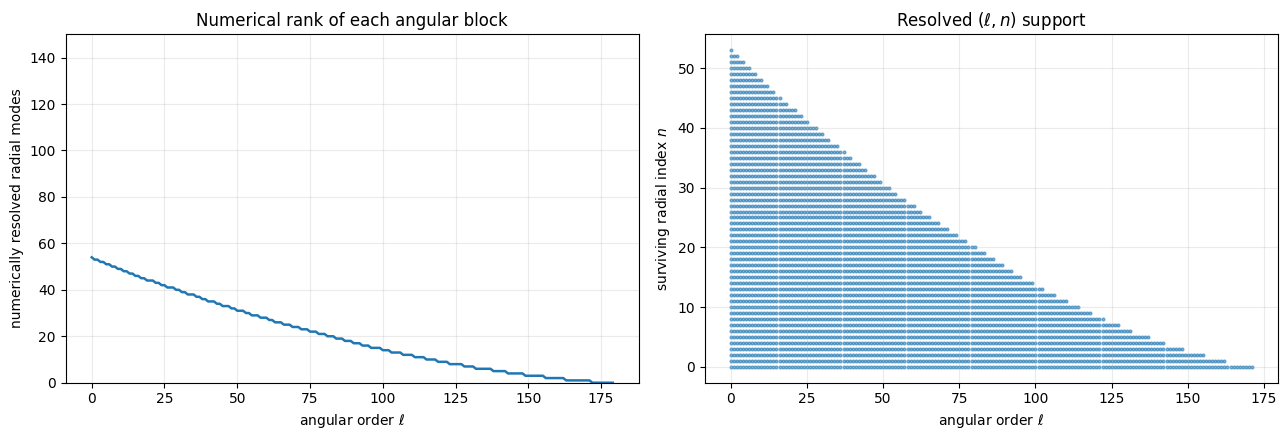

In [17]:
relative_tolerances = [0.0, EIGENVALUE_RELATIVE_TOLERANCE, 1e-12, 1e-10, 1e-8, 1e-6]
print("relative tolerance   surviving modes   retained trace   largest n")
for relative_tolerance in relative_tolerances:
    threshold = relative_tolerance * float(eigenvalues.max())
    mask = eigenvalues > threshold
    retained_trace = float(weighted_eigenvalues[mask].sum())
    maximum_n = int(np.argwhere(mask)[:, 1].max()) if np.any(mask) else -1
    label = "lambda > 0" if relative_tolerance == 0 else f"{relative_tolerance:.3g}"
    print(
        f"{label:>18}   {np.count_nonzero(mask):15,d}   "
        f"{retained_trace / weighted_eigenvalues.sum():13.9%}   {maximum_n:9d}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ells, surviving_per_ell, lw=1.8)
axes[0].set(
    xlabel=r"angular order $\ell$",
    ylabel="numerically resolved radial modes",
    title="Numerical rank of each angular block",
    ylim=(0, LEGENDRE_ORDER),
)
axes[0].grid(alpha=0.25)

axes[1].scatter(
    surviving_indices[:, 0], surviving_indices[:, 1], s=4, alpha=0.55,
)
axes[1].set(
    xlabel=r"angular order $\ell$",
    ylabel=r"surviving radial index $n$",
    title="Resolved $(\ell,n)$ support",
)
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()


### Numerical rank at the 99% angular ceiling

The full 180-order calculation is useful for establishing trace closure. The following cell separately reports the numerical rank of the smaller \(\ell=0,\ldots,134\) model identified by the angular 99% crossing.


In [18]:
order_99 = int(crossings[-1][1])
mask_99 = numerically_significant[:order_99]
counts_99 = mask_99.sum(axis=1)
indices_99 = np.argwhere(mask_99)
weighted_99 = weighted_eigenvalues[:order_99]
print(f"Angular ceiling:                   ell=0,...,{order_99 - 1}")
print(f"Nominal radial solutions:          {mask_99.size:,}")
print(f"Numerically resolved solutions:    {np.count_nonzero(mask_99):,}")
print(f"Largest surviving radial index n:  {indices_99[:, 1].max()}")
print(
    "Surviving modes per ell:         "
    f"min={counts_99.min()}, median={np.median(counts_99):.0f}, max={counts_99.max()}"
)
print(
    "Resolved fraction of ceiling trace: "
    f"{weighted_99[mask_99].sum() / weighted_99.sum():.12%}"
)


Angular ceiling:                   ell=0,...,134
Nominal radial solutions:          20,250
Numerically resolved solutions:    3,594
Largest surviving radial index n:  53
Surviving modes per ell:         min=6, median=25, max=54
Resolved fraction of ceiling trace: 99.999999999977%


## 6. Global radial-mode truncation and Cartesian-template cost

Angular truncation is only the first restriction. The detector globally sorts the positive radial modes \(\lambda_{\ell n}\). Keeping one \((\ell,n)\) mode requires the complete \(m=-\ell,\ldots,\ell\) multiplet—\(2\ell+1\) Cartesian score filters. Thus a cap of 1000 templates does **not** retain 1000 radial modes and may bind well before the requested 99% energy is reached.


target   radial modes   expanded templates   largest selected ell
   80%            404               26,762                    138
   90%            832               79,130                    143
   95%          1,393              134,841                    144
   99%          2,322              208,188                    146


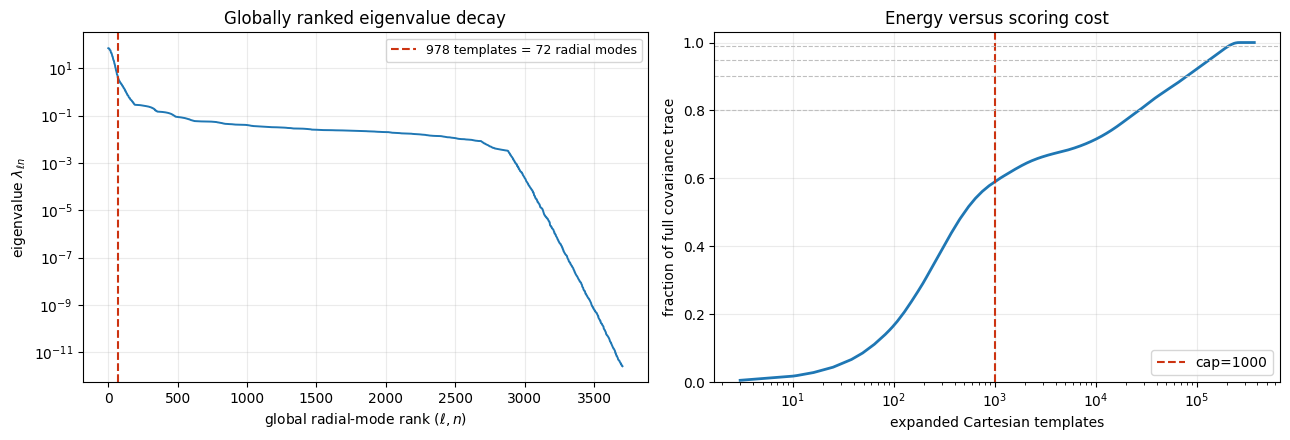

Cap 1,000 retains 72 radial modes / 978 complete templates.
Retained fraction of full covariance trace: 58.817886%


In [19]:
ell_grid, radial_grid = np.indices(eigenvalues.shape)
mode_values = eigenvalues[numerically_significant]
mode_ells = ell_grid[numerically_significant].astype(np.int64)
mode_ns = radial_grid[numerically_significant].astype(np.int64)

descending = np.argsort(mode_values, kind="stable")[::-1]
mode_values = mode_values[descending]
mode_ells = mode_ells[descending]
mode_ns = mode_ns[descending]
mode_multiplicities = 2 * mode_ells + 1
cumulative_templates = np.cumsum(mode_multiplicities)
cumulative_mode_fraction = (
    np.cumsum(mode_values * mode_multiplicities) / expected_trace
)

print("target   radial modes   expanded templates   largest selected ell")
for target in TRACE_TARGETS:
    index = int(np.flatnonzero(cumulative_mode_fraction >= target)[0])
    print(
        f"{target:6.0%}   {index + 1:12,d}   "
        f"{cumulative_templates[index]:18,d}   "
        f"{mode_ells[:index + 1].max():20d}"
    )

cap_index = int(np.searchsorted(cumulative_templates, TEMPLATE_CAP, side="right"))
cap_templates = int(cumulative_templates[cap_index - 1])
cap_fraction = float(cumulative_mode_fraction[cap_index - 1])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].semilogy(np.arange(1, len(mode_values) + 1), mode_values, lw=1.4)
axes[0].axvline(
    cap_index, color="#CC3311", ls="--",
    label=f"{cap_templates} templates = {cap_index} radial modes",
)
axes[0].set(
    xlabel=r"global radial-mode rank $(\ell,n)$",
    ylabel=r"eigenvalue $\lambda_{\ell n}$",
    title="Globally ranked eigenvalue decay",
)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

axes[1].semilogx(cumulative_templates, cumulative_mode_fraction, lw=2)
axes[1].axvline(TEMPLATE_CAP, color="#CC3311", ls="--", label=f"cap={TEMPLATE_CAP}")
for target in TRACE_TARGETS:
    axes[1].axhline(target, color="0.75", ls="--", lw=0.8)
axes[1].set(
    xlabel="expanded Cartesian templates",
    ylabel="fraction of full covariance trace",
    title="Energy versus scoring cost",
    ylim=(0, 1.03),
)
axes[1].legend()
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

print(f"Cap {TEMPLATE_CAP:,} retains {cap_index} radial modes / {cap_templates:,} complete templates.")
print(f"Retained fraction of full covariance trace: {cap_fraction:.6%}")


## 7. Angular ceiling and template budget are separate truncations

A larger max_order exposes more of the covariance spectrum, but it cannot recover modes removed by a fixed scoring-template budget. The next diagnostic distinguishes:

1. **available energy:** every mode with \(\ell <\) max_order;
2. **retained energy:** globally ranked modes under both the 99% target and the complete-multiplet template cap.


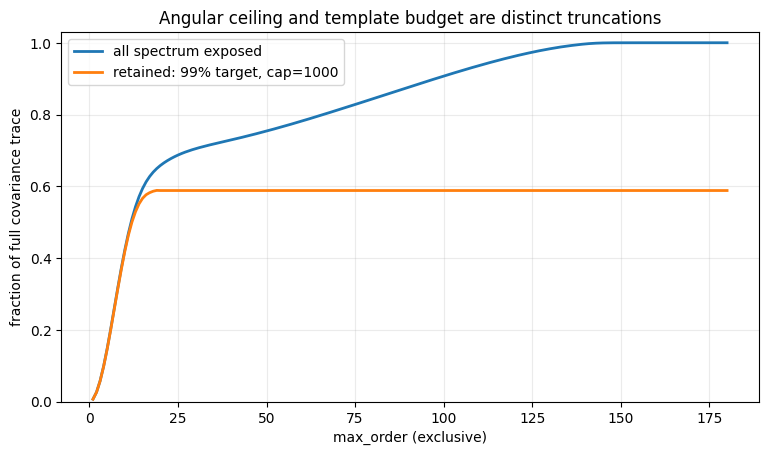

In [20]:
available_by_ceiling = []
retained_by_ceiling = []

for order_count in range(1, MAX_ORDER + 1):
    local_values = eigenvalues[:order_count]
    local_ell_grid, _ = np.indices(local_values.shape)
    local_significant = local_values > eigenvalue_tolerance
    values = local_values[local_significant]
    orders = local_ell_grid[local_significant]

    order = np.argsort(values, kind="stable")[::-1]
    values, orders = values[order], orders[order]
    multiplicities = 2 * orders + 1
    available_energy = float(np.sum(values * multiplicities))
    cumulative_energy = np.cumsum(values * multiplicities)
    cumulative_cost = np.cumsum(multiplicities)

    by_energy = int(np.searchsorted(
        cumulative_energy,
        ENERGY_FRACTION * available_energy,
        side="left",
    ) + 1)
    by_cap = int(np.searchsorted(cumulative_cost, TEMPLATE_CAP, side="right"))
    retained_count = min(by_energy, by_cap)
    retained_energy = (
        float(cumulative_energy[retained_count - 1]) if retained_count else 0.0
    )

    available_by_ceiling.append(available_energy / expected_trace)
    retained_by_ceiling.append(retained_energy / expected_trace)

max_orders = np.arange(1, MAX_ORDER + 1)
plt.figure(figsize=(9, 4.8))
plt.plot(max_orders, available_by_ceiling, lw=2, label="all spectrum exposed")
plt.plot(
    max_orders,
    retained_by_ceiling,
    lw=2,
    label=f"retained: {ENERGY_FRACTION:.0%} target, cap={TEMPLATE_CAP}",
)
plt.xlabel("max_order (exclusive)")
plt.ylabel("fraction of full covariance trace")
plt.title("Angular ceiling and template budget are distinct truncations")
plt.ylim(0, 1.03)
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## 8. Template-cap sensitivity

This sweep quantifies the computational price of retaining more covariance energy. Costs count complete \(m\) multiplets and therefore equal the actual number of Cartesian score filters, not merely the number of radial eigenfunctions.


requested cap   radial modes   complete templates   trace fraction
        1,000             72                  978      58.817886%
        2,000            118                1,994      64.279928%
        4,000            186                3,966      67.401576%
        8,000            253                7,969      70.191348%
       16,000            308               15,904      75.092768%
       32,000            442               31,958      81.743170%
       64,000            720               63,860      88.005248%
      128,000          1,316              127,940      94.513539%
      256,000          2,919              255,953      99.977532%


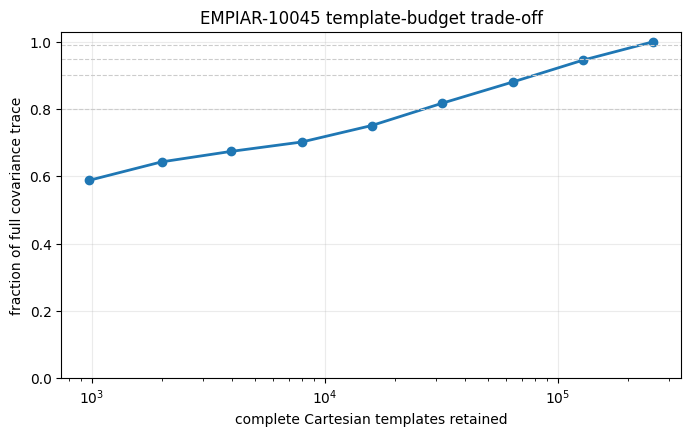

In [21]:
caps = np.asarray([1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000])
cap_rows = []
for requested_cap in caps:
    count = int(np.searchsorted(cumulative_templates, requested_cap, side="right"))
    used = int(cumulative_templates[count - 1]) if count else 0
    fraction = float(cumulative_mode_fraction[count - 1]) if count else 0.0
    cap_rows.append((requested_cap, count, used, fraction))

print("requested cap   radial modes   complete templates   trace fraction")
for requested_cap, count, used, fraction in cap_rows:
    print(f"{requested_cap:13,d}   {count:12,d}   {used:18,d}   {fraction:13.6%}")

plt.figure(figsize=(8, 4.5))
plt.semilogx(
    [row[2] for row in cap_rows],
    [row[3] for row in cap_rows],
    "o-",
    lw=2,
)
for target in TRACE_TARGETS:
    plt.axhline(target, color="0.8", ls="--", lw=0.8)
plt.xlabel("complete Cartesian templates retained")
plt.ylabel("fraction of full covariance trace")
plt.title("EMPIAR-10045 template-budget trade-off")
plt.ylim(0, 1.03)
plt.grid(alpha=0.25)
plt.show()


## 9. Reproducible conclusion

The cell below derives the conclusion from the loaded checkpoint rather than hard-coding it. This is the compact record to use when choosing a new max_order and scoring-template budget.


In [22]:
summary = {
    "source_results": str(RESULTS_DIR.resolve()),
    "legendre_order": LEGENDRE_ORDER,
    "max_order_exclusive": MAX_ORDER,
    "largest_solved_ell": MAX_ORDER - 1,
    "support_radius_voxels": support_radius,
    "bandlimit_radians_per_voxel": bandlimit,
    "space_bandwidth_product": support_radius * bandlimit,
    "expected_covariance_trace": expected_trace,
    "solved_trace_fraction": float(cumulative_trace_fraction[-1]),
    "eigenvalue_relative_tolerance": EIGENVALUE_RELATIVE_TOLERANCE,
    "eigenvalue_absolute_tolerance": eigenvalue_tolerance,
    "nominal_radial_solutions": int(eigenvalues.size),
    "strictly_positive_radial_solutions": positive_count,
    "numerically_resolved_radial_solutions": significant_count,
    "largest_surviving_radial_index": largest_surviving_n,
    "discarded_numerical_trace_fraction": discarded_trace_fraction,
    "angular_crossings": {
        f"{target:.2f}": {
            "max_order": order_count,
            "largest_ell": largest_ell,
            "fraction": achieved,
        }
        for target, order_count, largest_ell, achieved in crossings
    },
    "template_cap": TEMPLATE_CAP,
    "retained_radial_modes": cap_index,
    "retained_complete_templates": cap_templates,
    "retained_trace_fraction": cap_fraction,
}
print(json.dumps(summary, indent=2))

display(Markdown(
    "### Interpretation for this checkpoint\n"
    f"- The current detector setting max_order=4 exposes only "
    f"**{available_by_ceiling[3]:.2%}** of the high-order covariance trace.\n"
    f"- Reaching 99% by angular ceiling alone first requires "
    f"**max_order={crossings[-1][1]}** (through \(\ell={crossings[-1][2]}\)).\n"
    f"- The separate cap of {TEMPLATE_CAP:,} permits {cap_templates:,} complete templates "
    f"and retains **{cap_fraction:.2%}** of the full trace.\n"
    "- Therefore max_order and max_templates must be selected together; increasing only "
    "the angular ceiling cannot deliver 99% retained energy under the current cap."
))


{
  "source_results": "/scratch/home/moshemaymon/3D_KLT/results/empiar-10045-bandpass-block-qr",
  "legendre_order": 150,
  "max_order_exclusive": 180,
  "largest_solved_ell": 179,
  "support_radius_voxels": 47.4433992815174,
  "bandlimit_radians_per_voxel": 3.141592653589793,
  "space_bandwidth_product": 149.04783464414234,
  "expected_covariance_trace": 39502.68669856438,
  "solved_trace_fraction": 1.0000000000000002,
  "eigenvalue_relative_tolerance": 3.3306690738754696e-14,
  "eigenvalue_absolute_tolerance": 2.335436552565282e-12,
  "nominal_radial_solutions": 27000,
  "strictly_positive_radial_solutions": 3839,
  "numerically_resolved_radial_solutions": 3705,
  "largest_surviving_radial_index": 53,
  "discarded_numerical_trace_fraction": 3.3306690738754696e-13,
  "angular_crossings": {
    "0.80": {
      "max_order": 67,
      "largest_ell": 66,
      "fraction": 0.8030428562495011
    },
    "0.90": {
      "max_order": 98,
      "largest_ell": 97,
      "fraction": 0.9008865581

### Interpretation for this checkpoint
- The current detector setting max_order=4 exposes only **9.84%** of the high-order covariance trace.
- Reaching 99% by angular ceiling alone first requires **max_order=135** (through \(\ell=134\)).
- The separate cap of 1,000 permits 978 complete templates and retains **58.82%** of the full trace.
- Therefore max_order and max_templates must be selected together; increasing only the angular ceiling cannot deliver 99% retained energy under the current cap.